# Logistic Regression con validacion LOSO (etiquetas individuales)

Este notebook implementa el **Experimento A** con features derivadas de HR/R-R y ECG.

El objetivo es evaluar la generalizacion a un trabajador no visto mediante Leave-One-Subject-Out Cross-Validation (LOSO). Cada trabajador obtiene sus propios umbrales P33/P66 calculados sobre todo su registro `FatigueIndex`, y las etiquetas resultantes se guardan en `FatigueLevel`.

## Etiquetado individual

1. Para cada trabajador se calculan P33 y P66 usando todo su `FatigueIndex` valido.
2. Se crean las etiquetas `Low`, `Medium` y `High` en `FatigueLevel` con esos umbrales propios.
3. LOSO usa directamente `FatigueLevel` en TRAIN y TEST; no se recalculan umbrales globales dentro del fold.
4. Los imputadores y scalers se ajustan solo con TRAIN.

Las entradas son las columnas `_z`, normalizadas respecto a la baseline individual de cada trabajador. `FatigueIndex` no se usa como feature.

In [13]:
from pathlib import Path

import json
import joblib
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

current_dir = Path.cwd()
candidate_roots = [
    current_dir,
    current_dir.parent,
    current_dir.parent.parent,
    current_dir.parent.parent.parent,
    current_dir / 'new',
]
ROOT_DIR = next(
    (
        candidate
        for candidate in candidate_roots
        if (candidate / 'W00' / 'PROCESSED' / 'combined_features_1min.csv').exists()
    ),
    current_dir,
)
DATA_DIR = ROOT_DIR
BASELINE_WINDOW_COUNT = 15
TARGET_COLUMN_CANDIDATES = ['FatigueIndex', 'fatigue_index']
LABELS = ['Low', 'Medium', 'High']
C_GRID = [0.01, 0.1, 1, 10, 100.0, 300.0, 1000.0, 3000.0, 10000.0]

print(f'Directorio de datos: {DATA_DIR}')

Directorio de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new


## Carga de datos

Cada CSV corresponde a un trabajador. El nombre de la carpeta (`W00`, ..., `W08`) se conserva como identificador para construir los folds, pero nunca entra como feature del modelo.

In [14]:
def make_labels(fatigue_values, p33, p66):
    return pd.cut(
        fatigue_values,
        bins=[-np.inf, p33, p66, np.inf],
        labels=LABELS,
        right=False,
    ).astype(object)


worker_files = {
    worker_dir.name: worker_dir / 'PROCESSED' / 'combined_features_1min.csv'
    for worker_dir in sorted(DATA_DIR.glob('W[0-9][0-9]'))
    if (worker_dir / 'PROCESSED' / 'combined_features_1min.csv').exists()
}
if len(worker_files) < 2:
    raise ValueError(f'Se necesitan al menos 2 trabajadores procesados y se encontraron {len(worker_files)}: {list(worker_files)}')

data = {}
for worker, path in worker_files.items():
    frame = pd.read_csv(path)
    target_matches = [column for column in TARGET_COLUMN_CANDIDATES if column in frame.columns]
    if len(target_matches) != 1:
        raise ValueError(f'{worker}: no se encontro exactamente una columna FatigueIndex/fatigue_index')
    frame = frame.rename(columns={target_matches[0]: 'FatigueIndex'})
    worker_fatigue = pd.to_numeric(frame['FatigueIndex'], errors='coerce')
    valid_fatigue = worker_fatigue.dropna()
    if valid_fatigue.empty:
        raise ValueError(f'{worker}: no contiene valores validos de FatigueIndex')
    worker_p33, worker_p66 = np.percentile(valid_fatigue, [33, 66])
    frame['P33_worker'] = worker_p33
    frame['P66_worker'] = worker_p66
    frame['FatigueLevel'] = make_labels(worker_fatigue, worker_p33, worker_p66)
    frame['Trabajador'] = worker
    data[worker] = frame

feature_columns = [
    'ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z',
    'ECG_samp_ent_z', 'ECG_std_z', 'HR_max_z', 'HR_mean_z', 'HR_min_z',
    'RMSSD_z', 'SDNN_z', 'pNN50_z', 'HR_mean_ultimos_5min_z',
    'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z',
]
missing_features = [column for column in feature_columns if column not in data[next(iter(data))].columns]
if missing_features:
    raise ValueError(f'Faltan features requeridas: {missing_features}')
if not feature_columns:
    raise ValueError('No se encontraron columnas de entrada terminadas en _z')

print('Trabajadores:', list(data))
print('Features del Experimento A:', feature_columns)
print('Ventanas:', {worker: len(frame) for worker, frame in data.items()})

Trabajadores: ['W00', 'W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08', 'W09']
Features del Experimento A: ['ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z', 'ECG_samp_ent_z', 'ECG_std_z', 'HR_max_z', 'HR_mean_z', 'HR_min_z', 'RMSSD_z', 'SDNN_z', 'pNN50_z', 'HR_mean_ultimos_5min_z', 'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z']
Ventanas: {'W00': 104, 'W01': 637, 'W02': 603, 'W03': 407, 'W04': 562, 'W05': 74, 'W06': 35, 'W07': 67, 'W08': 133, 'W09': 16}


## Funciones de target y evaluacion

Los percentiles se calculan en cada fold y solo con el vector de `FatigueIndex` de TRAIN. Los valores faltantes del target no se usan para calcular percentiles ni para entrenar/evaluar ese fold.

In [15]:
def make_labels(fatigue_values, p33, p66):
    return pd.cut(fatigue_values, bins=[-np.inf, p33, p66, np.inf], labels=LABELS, right=False).astype(object)


def build_model(C=1.0):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            C=C, penalty='l2', class_weight='balanced', max_iter=2000, random_state=42,
        )),
    ])


def optimize_model(X_train, y_train):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = GridSearchCV(
        estimator=build_model(), param_grid={'classifier__C': C_GRID},
        scoring='balanced_accuracy', cv=inner_cv, refit=True, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    return search

## Experimento A

Features utilizadas: todas las columnas `_z` disponibles, que corresponden a features derivadas de HR/R-R y ECG.

La matriz de confusion utiliza siempre el orden `Low`, `Medium`, `High`.

In [16]:
fold_results = []
confusion_matrices = {}

for test_worker in sorted(data):
    train_workers = [worker for worker in sorted(data) if worker != test_worker]
    train_frame = pd.concat([data[worker] for worker in train_workers], ignore_index=True)
    test_frame = data[test_worker].copy()
    train_target = train_frame['FatigueLevel']
    test_target = test_frame['FatigueLevel']
    train_mask = train_target.notna()
    test_mask = test_target.notna()
    X_train = train_frame.loc[train_mask, feature_columns]
    y_train = train_target.loc[train_mask]
    X_test = test_frame.loc[test_mask, feature_columns]
    y_test = test_target.loc[test_mask]
    if y_train.nunique() < 2:
        raise ValueError(f'{test_worker}: TRAIN tiene menos de dos clases')
    search = optimize_model(X_train, y_train)
    y_pred = search.predict(X_test)
    confusion_matrices[test_worker] = confusion_matrix(y_test, y_pred, labels=LABELS)
    matrix = confusion_matrices[test_worker]
    class_recall = np.divide(np.diag(matrix), matrix.sum(axis=1), out=np.zeros(3, dtype=float), where=matrix.sum(axis=1) != 0)
    fold_results.append({
        'Test_worker': test_worker, 'Train_workers': ', '.join(train_workers),
        'P33_worker_test': test_frame['P33_worker'].iloc[0], 'P66_worker_test': test_frame['P66_worker'].iloc[0],
        'N_train': len(y_train), 'N_test': len(y_test), 'Best_C': search.best_params_['classifier__C'],
        'Recall_Low': class_recall[0], 'Recall_Medium': class_recall[1], 'Recall_High': class_recall[2],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Macro_F1': f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0),
    })

fold_results_df = pd.DataFrame(fold_results)
mean_row = {column: np.nan for column in fold_results_df.columns}
mean_row['Test_worker'] = 'Media'
mean_row['Train_workers'] = 'Promedio de los folds'
for metric in ['P33_worker_test', 'P66_worker_test', 'N_train', 'N_test', 'Best_C', 'Recall_Low', 'Recall_Medium', 'Recall_High', 'Accuracy', 'Balanced_Accuracy', 'Macro_F1']:
    mean_row[metric] = fold_results_df[metric].mean()
fold_results_with_mean = pd.concat([fold_results_df, pd.DataFrame([mean_row])], ignore_index=True)
fold_results_with_mean

,Test_worker,Train_workers,P33_worker_test,P66_worker_test,N_train,N_test,Best_C,Recall_Low,Recall_Medium,Recall_High,Accuracy,Balanced_Accuracy,Macro_F1
0,W00,"W01, W02, W03, W04, W05, W06, W07, W08, W09",-4.910791,-2.404562,2534.0,104.0,100.0,1.000000,0.000000,0.250000,0.413462,0.416667,0.319126
1,W01,"W00, W02, W03, W04, W05, W06, W07, W08, W09",0.198577,1.995281,2001.0,637.0,100.0,0.680952,0.752381,0.976959,0.805338,0.803431,0.801153
2,W02,"W00, W01, W03, W04, W05, W06, W07, W08, W09",0.158699,1.895113,2035.0,603.0,3000.0,0.502513,0.638191,0.917073,0.688226,0.685926,0.681523
3,W03,"W00, W01, W02, W04, W05, W06, W07, W08, W09",2.647584,6.383634,2231.0,407.0,100.0,0.492537,0.082090,1.000000,0.530713,0.524876,0.478203
4,W04,"W00, W01, W02, W03, W05, W06, W07, W08, W09",-0.665957,-0.261558,2076.0,562.0,100.0,1.000000,0.000000,0.026178,0.339858,0.342059,0.211060
5,W05,"W00, W01, W02, W03, W04, W06, W07, W08, W09",-0.187187,1.001664,2564.0,74.0,100.0,0.680000,0.666667,0.520000,0.621622,0.622222,0.626368
6,W06,"W00, W01, W02, W03, W04, W05, W07, W08, W09",-2.177750,0.344163,2603.0,35.0,100.0,1.000000,0.545455,0.666667,0.742857,0.737374,0.738889
7,W07,"W00, W01, W02, W03, W04, W05, W06, W08, W09",1.321727,2.733179,2571.0,67.0,100.0,0.863636,0.136364,0.739130,0.582090,0.579710,0.530227
8,W08,"W00, W01, W02, W03, W04, W05, W06, W07, W09",-0.755704,-0.078134,2505.0,133.0,3000.0,0.977273,0.068182,0.044444,0.360902,0.363300,0.250958
9,W09,"W00, W01, W02, W03, W04, W05, W06, W07, W08",0.108181,2.299379,2622.0,16.0,100.0,1.000000,0.200000,0.833333,0.687500,0.677778,0.650794


In [17]:
print('Matrices de confusion por trabajador TEST:')
for worker, matrix in confusion_matrices.items():
    print(f'\nTEST = {worker}')
    print(pd.DataFrame(matrix, index=LABELS, columns=LABELS))

metrics = ['Accuracy', 'Balanced_Accuracy', 'Macro_F1']
summary_df = pd.DataFrame({'Metric': metrics, 'Mean': [fold_results_df[metric].mean() for metric in metrics], 'Std': [fold_results_df[metric].std(ddof=1) for metric in metrics]})
print('Media y desviacion estandar de las metricas:')
display(summary_df)

aggregate_confusion = np.sum(np.stack([confusion_matrices[worker] for worker in sorted(confusion_matrices)]), axis=0)
display(pd.DataFrame(aggregate_confusion, index=LABELS, columns=LABELS))
class_support = aggregate_confusion.sum(axis=1)
predicted_support = aggregate_confusion.sum(axis=0)
class_metrics_df = pd.DataFrame({'Support': class_support, 'Recall': np.divide(np.diag(aggregate_confusion), class_support, out=np.zeros(3, dtype=float), where=class_support != 0), 'Precision': np.divide(np.diag(aggregate_confusion), predicted_support, out=np.zeros(3, dtype=float), where=predicted_support != 0)}, index=LABELS)
display(class_metrics_df.round(3))

distribution_rows = []
for worker, frame in data.items():
    counts = frame['FatigueLevel'].value_counts().reindex(LABELS, fill_value=0)
    distribution_rows.append({'Test_worker': worker, 'Low': int(counts['Low']), 'Medium': int(counts['Medium']), 'High': int(counts['High']), 'Total_valid': int(counts.sum())})
print('Distribucion individual de clases por trabajador:')
display(pd.DataFrame(distribution_rows))

Matrices de confusion por trabajador TEST:

TEST = W00
        Low  Medium  High
Low      34       0     0
Medium   34       0     0
High     20       7     9

TEST = W01
        Low  Medium  High
Low     143      67     0
Medium   15     158    37
High      4       1   212

TEST = W02
        Low  Medium  High
Low     100      96     3
Medium    1     127    71
High      7      10   188

TEST = W03
        Low  Medium  High
Low      66      50    18
Medium    1      11   122
High      0       0   139

TEST = W04
        Low  Medium  High
Low     186       0     0
Medium  185       0     0
High     82     104     5

TEST = W05
        Low  Medium  High
Low      17       8     0
Medium    4      16     4
High      2      10    13

TEST = W06
        Low  Medium  High
Low      12       0     0
Medium    5       6     0
High      3       1     8

TEST = W07
        Low  Medium  High
Low      19       1     2
Medium   16       3     3
High      5       1    17

TEST = W08
        Low  Medi

,Metric,Mean,Std
0,Accuracy,0.577257,0.162640
1,Balanced_Accuracy,0.575334,0.159974
2,Macro_F1,0.528830,0.208359


,Low,Medium,High
Low,625,222,24
Medium,302,325,241
High,142,159,598


,Support,Recall,Precision
Low,871,0.718,0.585
Medium,868,0.374,0.460
High,899,0.665,0.693


Distribucion individual de clases por trabajador:


,Test_worker,Low,Medium,High,Total_valid
0,W00,34,34,36,104
1,W01,210,210,217,637
2,W02,199,199,205,603
3,W03,134,134,139,407
4,W04,186,185,191,562
5,W05,25,24,25,74
6,W06,12,11,12,35
7,W07,22,22,23,67
8,W08,44,44,45,133
9,W09,5,5,6,16


In [18]:
comparison_df = pd.DataFrame({
    'Modelo': [
        'Original sin variables temporales',
        'Temporal original',
        'Optimizado anterior',
        'Optimizado con cuadrícula ampliada',
        'Optimizado con cuadrícula ampliada',
    ],
    'class_weight': ['None', 'None', 'balanced', 'balanced', 'balanced'],
    'C por fold': [
        '1.0',
        '1.0',
        '100 en los 5 folds',
        'W00: 10000; W01: 3000; W02: 10000; W03: 3000; ...',
        'W00: 1000; W01: 10000; W02: 3000; W03: 3000; W...',
    ],
    'C final': [
        '1.0',
        '1.0',
        '100',
        '10000.0',
        '3000.0',
    ],
    'Accuracy': [
        0.781303,
        0.783572,
        0.844313,
        0.8510,
        0.781666,
    ],
    'Balanced Accuracy': [
        0.679752,
        0.692432,
        0.702434,
        0.7319,
        0.742559,
    ],
    'Macro-F1': [
        0.652589,
        0.667675,
        0.681970,
        0.7111,
        0.700735,
    ],
})

for column in ['Accuracy', 'Balanced Accuracy', 'Macro-F1']:
    comparison_df[column] = comparison_df[column].map(
        lambda value: f'{value:.2%}'
    )

display(comparison_df)

,Modelo,class_weight,C por fold,C final,Accuracy,Balanced Accuracy,Macro-F1
0,Original sin variables temporales,None,1.0,1.0,78.13%,67.98%,65.26%
1,Temporal original,None,1.0,1.0,78.36%,69.24%,66.77%
2,Optimizado anterior,balanced,100 en los 5 folds,100,84.43%,70.24%,68.20%
3,Optimizado con cuadrícula ampliada,balanced,W00: 10000; W01: 3000; W02: 10000; W03: 3000; ...,10000.0,85.10%,73.19%,71.11%
4,Optimizado con cuadrícula ampliada,balanced,W00: 1000; W01: 10000; W02: 3000; W03: 3000; W...,3000.0,78.17%,74.26%,70.07%


## Modelo final y exportacion

La evaluacion LOSO anterior mide la generalizacion dejando un trabajador fuera en cada fold. Despues, este bloque reentrena un modelo final con todos los trabajadores y todas las ventanas validas. Este modelo final es el que se utilizara para la aplicacion.

El modelo y el preprocesamiento completo se guardan en formato `joblib`, el modelo para Expo/React Native en formato `ONNX`, y la configuracion en un archivo `JSON`. Los modelos individuales se guardan en `new/models/individual/LOGISTIC_REGRESSION/`, separados de los modelos globales.

In [19]:
# Reentrenamiento final con etiquetas relativas a cada trabajador
all_frame = pd.concat([data[worker] for worker in sorted(data)], ignore_index=True)
all_target = all_frame['FatigueLevel']
all_mask = all_target.notna()
X_all = all_frame.loc[all_mask, feature_columns]
y_all = all_target.loc[all_mask]

final_search = optimize_model(X_all, y_all)
final_model = final_search.best_estimator_

models_dir = ROOT_DIR / 'models' / 'individual' / 'LOGISTIC_REGRESSION'
models_dir.mkdir(parents=True, exist_ok=True)
joblib_path = models_dir / 'final_logistic_regression_individual.joblib'
onnx_path = models_dir / 'final_logistic_regression_individual.onnx'
metadata_path = models_dir / 'final_logistic_regression_individual_metadata.json'

joblib.dump(final_model, joblib_path)
onnx_model = convert_sklearn(final_model, initial_types=[('features', FloatTensorType([None, len(feature_columns)]))])
onnx_path.write_bytes(onnx_model.SerializeToString())

metadata = {
    'model_type': 'LogisticRegression', 'validation': 'LOSO_individual_worker_percentiles_with_inner_C_search',
    'training_workers': sorted(data), 'feature_columns': feature_columns, 'feature_count': len(feature_columns),
    'labels': LABELS, 'label_definition': 'P33/P66 calculated independently for each worker over the full FatigueIndex record',
    'class_weight': 'balanced', 'C_grid': C_GRID,
    'selected_C_final': float(final_search.best_params_['classifier__C']),
    'target_column': 'FatigueIndex', 'target_label_column': 'FatigueLevel',
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print(f'Modelo final entrenado con {len(y_all)} ventanas y {len(feature_columns)} features')
print(f'C final seleccionado: {final_search.best_params_["classifier__C"]}')
print(f'Guardado en: {models_dir}')

Modelo final entrenado con 2638 ventanas y 16 features
C final seleccionado: 100.0
Guardado en: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\models\individual\LOGISTIC_REGRESSION


## Experimento B: ablacion HR/R-R

Se conservan solo las features calculadas a partir de HR/R-R y las cuatro features temporales. Se eliminan las features ECG. El target sigue siendo el `FatigueIndex` categorico creado dentro de cada fold con P33 y P66 de TRAIN.

In [20]:
HR_RR_FEATURES = ['SDNN_z', 'RMSSD_z', 'pNN50_z', 'HR_mean_z', 'HR_max_z', 'HR_min_z', 'HR_mean_ultimos_5min_z', 'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z']
ECG_FEATURES = ['ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z', 'ECG_samp_ent_z', 'ECG_std_z']


def run_ablation_experiment(experiment_name, selected_features):
    results = []
    for test_worker in sorted(data):
        train_workers = [worker for worker in sorted(data) if worker != test_worker]
        train_frame = pd.concat([data[worker] for worker in train_workers], ignore_index=True)
        test_frame = data[test_worker].copy()
        train_target, test_target = train_frame['FatigueLevel'], test_frame['FatigueLevel']
        train_mask, test_mask = train_target.notna(), test_target.notna()
        X_train, y_train = train_frame.loc[train_mask, selected_features], train_target.loc[train_mask]
        X_test, y_test = test_frame.loc[test_mask, selected_features], test_target.loc[test_mask]
        search = optimize_model(X_train, y_train)
        y_pred = search.predict(X_test)
        results.append({'Experiment': experiment_name, 'Test_worker': test_worker, 'N_train': len(y_train), 'N_test': len(y_test), 'Feature_count': len(selected_features), 'Best_C': search.best_params_['classifier__C'], 'Accuracy': accuracy_score(y_test, y_pred), 'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred), 'Macro_F1': f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0)})
    return pd.DataFrame(results)


def add_mean_row(results_frame):
    mean_row = {column: np.nan for column in results_frame.columns}
    mean_row['Test_worker'] = 'Media'
    for column in results_frame.select_dtypes(include='number').columns:
        mean_row[column] = results_frame[column].mean()
    return pd.concat([results_frame, pd.DataFrame([mean_row])], ignore_index=True)


hr_rr_results = run_ablation_experiment('Solo HR/RR + temporales', HR_RR_FEATURES)
hr_rr_results_with_mean = add_mean_row(hr_rr_results)
print('Resultados del Experimento B por trabajador y promedio:')
display(hr_rr_results_with_mean.round(4))

Resultados del Experimento B por trabajador y promedio:


,Experiment,Test_worker,N_train,N_test,Feature_count,Best_C,Accuracy,Balanced_Accuracy,Macro_F1
0,Solo HR/RR + temporales,W00,2534.0,104.0,10.0,0.100,0.3750,0.3796,0.2530
1,Solo HR/RR + temporales,W01,2001.0,637.0,10.0,0.010,0.4804,0.4813,0.4220
2,Solo HR/RR + temporales,W02,2035.0,603.0,10.0,0.010,0.4726,0.4744,0.4191
3,Solo HR/RR + temporales,W03,2231.0,407.0,10.0,0.100,0.5430,0.5374,0.5022
4,Solo HR/RR + temporales,W04,2076.0,562.0,10.0,0.010,0.3897,0.3938,0.2824
5,Solo HR/RR + temporales,W05,2564.0,74.0,10.0,0.010,0.4865,0.4883,0.4664
6,Solo HR/RR + temporales,W06,2603.0,35.0,10.0,0.010,0.6000,0.5859,0.5202
7,Solo HR/RR + temporales,W07,2571.0,67.0,10.0,0.100,0.5224,0.5204,0.4313
8,Solo HR/RR + temporales,W08,2505.0,133.0,10.0,0.010,0.3459,0.3481,0.2319
9,Solo HR/RR + temporales,W09,2622.0,16.0,10.0,0.010,0.7500,0.7667,0.7527


## Experimento C: ablacion ECG

Se conservan solo las features calculadas a partir del ECG. Se excluyen las features HR/R-R y las temporales, porque estas ultimas dependen de HR/R-R. `ECG_missing_peaks` se conserva como feature de calidad de picos ECG. El target sigue siendo el `FatigueIndex` categorico creado dentro de cada fold con P33 y P66 de TRAIN.

In [24]:
ecg_results = run_ablation_experiment('Solo ECG', ECG_FEATURES)
ecg_results_with_mean = add_mean_row(ecg_results)
print('Resultados del Experimento C por trabajador y promedio:')
display(ecg_results_with_mean.round(4))

ec_results = pd.concat([hr_rr_results, ecg_results], ignore_index=True)
ablation_summary = (
    ec_results.groupby('Experiment')[['Accuracy', 'Balanced_Accuracy', 'Macro_F1']]
    .agg(['mean', 'std'])
    .round(4)
)
print('Resumen de las ablaciones:')
display(ablation_summary)

logistic_summary = pd.DataFrame({
    'Experiment': [
        'A: ECG + HR/RR + temporales',
        'B: HR/RR + temporales',
        'C: ECG',
    ],
    'Feature_count': [
        len(feature_columns),
        len(HR_RR_FEATURES),
        len(ECG_FEATURES),
    ],
    'Accuracy_mean': [
        fold_results_df['Accuracy'].mean(),
        hr_rr_results['Accuracy'].mean(),
        ecg_results['Accuracy'].mean(),
    ],
    'Balanced_Accuracy_mean': [
        fold_results_df['Balanced_Accuracy'].mean(),
        hr_rr_results['Balanced_Accuracy'].mean(),
        ecg_results['Balanced_Accuracy'].mean(),
    ],
    'Macro_F1_mean': [
        fold_results_df['Macro_F1'].mean(),
        hr_rr_results['Macro_F1'].mean(),
        ecg_results['Macro_F1'].mean(),
    ],
})
print('Resumen comparativo de los experimentos Logistic Regression:')
display(logistic_summary.round(4))

Resultados del Experimento C por trabajador y promedio:


,Experiment,Test_worker,N_train,N_test,Feature_count,Best_C,Accuracy,Balanced_Accuracy,Macro_F1
0,Solo ECG,W00,2534.0,104.0,6.0,3000.0,0.4519,0.4559,0.4219
1,Solo ECG,W01,2001.0,637.0,6.0,100.0,0.7017,0.7013,0.6999
2,Solo ECG,W02,2035.0,603.0,6.0,100.0,0.6600,0.6595,0.6591
3,Solo ECG,W03,2231.0,407.0,6.0,10000.0,0.5160,0.5111,0.4786
4,Solo ECG,W04,2076.0,562.0,6.0,10.0,0.3381,0.3403,0.1936
5,Solo ECG,W05,2564.0,74.0,6.0,1000.0,0.5676,0.5706,0.5660
6,Solo ECG,W06,2603.0,35.0,6.0,1000.0,0.4286,0.4242,0.3798
7,Solo ECG,W07,2571.0,67.0,6.0,10000.0,0.4328,0.4348,0.4209
8,Solo ECG,W08,2505.0,133.0,6.0,3000.0,0.5263,0.5300,0.4589
9,Solo ECG,W09,2622.0,16.0,6.0,10000.0,0.6250,0.6111,0.6019


Resumen de las ablaciones:


Accuracy         Balanced_Accuracy         Macro_F1  \
                            mean     std              mean     std     mean   
Experiment                                                                    
Solo ECG                  0.5248  0.1152            0.5239  0.1136   0.4881   
Solo HR/RR + temporales   0.4965  0.1191            0.4976  0.1203   0.4281   

                                 
                            std  
Experiment                       
Solo ECG                 0.1496  
Solo HR/RR + temporales  0.1532

Resumen comparativo de los experimentos Logistic Regression:


,Experiment,Feature_count,Accuracy_mean,Balanced_Accuracy_mean,Macro_F1_mean
0,A: ECG + HR/RR + temporales,16,0.5773,0.5753,0.5288
1,B: HR/RR + temporales,10,0.4965,0.4976,0.4281
2,C: ECG,6,0.5248,0.5239,0.4881


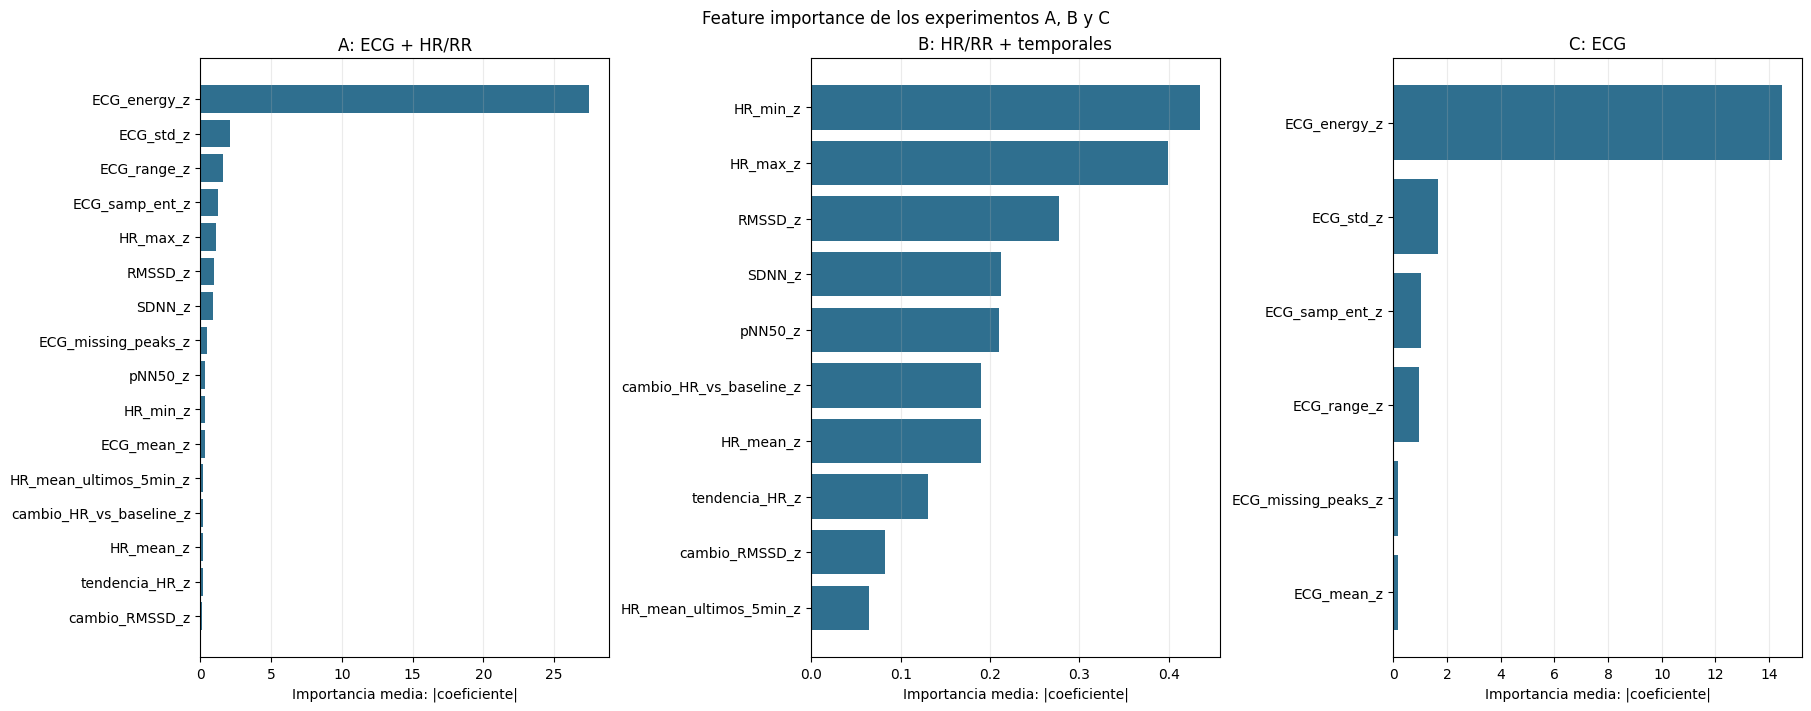

Features ordenadas por importancia:

A: ECG + HR/RR


,Feature,Importance
0,ECG_energy_z,27.4857
5,ECG_std_z,2.0962
3,ECG_range_z,1.6152
4,ECG_samp_ent_z,1.2734
6,HR_max_z,1.1078
9,RMSSD_z,0.9722
10,SDNN_z,0.8509
2,ECG_missing_peaks_z,0.4513
11,pNN50_z,0.3457
8,HR_min_z,0.3017



B: HR/RR + temporales


,Feature,Importance
5,HR_min_z,0.4350
4,HR_max_z,0.3985
1,RMSSD_z,0.2770
0,SDNN_z,0.2117
2,pNN50_z,0.2103
7,cambio_HR_vs_baseline_z,0.1895
3,HR_mean_z,0.1895
8,tendencia_HR_z,0.1301
9,cambio_RMSSD_z,0.0826
6,HR_mean_ultimos_5min_z,0.0646



C: ECG


,Feature,Importance
0,ECG_energy_z,14.4865
5,ECG_std_z,1.6607
4,ECG_samp_ent_z,1.0198
3,ECG_range_z,0.9530
2,ECG_missing_peaks_z,0.1912
1,ECG_mean_z,0.1825


In [22]:
import matplotlib.pyplot as plt


def fit_final_feature_model(selected_features):
    X_selected = all_frame.loc[all_mask, selected_features]
    return optimize_model(X_selected, y_all).best_estimator_


models_by_experiment = {
    'A: ECG + HR/RR': (feature_columns, fit_final_feature_model(feature_columns)),
    'B: HR/RR + temporales': (HR_RR_FEATURES, fit_final_feature_model(HR_RR_FEATURES)),
    'C: ECG': (ECG_FEATURES, fit_final_feature_model(ECG_FEATURES)),
}

importance_tables = {}
for experiment_name, (selected_features, model) in models_by_experiment.items():
    coefficients = model.named_steps['classifier'].coef_
    importance = np.mean(np.abs(coefficients), axis=0)
    importance_tables[experiment_name] = (
        pd.DataFrame({'Feature': selected_features, 'Importance': importance})
        .sort_values('Importance', ascending=True)
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)
for axis, (experiment_name, importance_table) in zip(axes, importance_tables.items()):
    axis.barh(importance_table['Feature'], importance_table['Importance'], color='#2f6f8f')
    axis.set_title(experiment_name)
    axis.set_xlabel('Importancia media: |coeficiente|')
    axis.grid(axis='x', alpha=0.25)

fig.suptitle('Feature importance de los experimentos A, B y C')
plt.show()

print('Features ordenadas por importancia:')
for experiment_name, importance_table in importance_tables.items():
    print(f'\n{experiment_name}')
    display(importance_table.sort_values('Importance', ascending=False).round(4))